# Barrow liquid-containing cloud susceptibility to LWP and duration thresholds

**Source:** DOE ARM observations at Utqiagvik (Barrow), NSA site, supplied by
Genie Lorenzo Pearson. Eleven cold seasons, 2014/15 through 2024/25,
Oct 1 - Mar 31.

Genie's phase classification is finer than anything ERA5 supports, because it
is built from the ARM radar/lidar/MWR suite. Three of her categories sum to
**liquid-containing**:

| category | meaning |
|---|---|
| `liq_only` | liquid only for the whole cloud episode |
| `liq_mixed` | episode contains both liquid-only and mixed-phase periods |
| `mixed_only` | mixed-phase only |

## Two interchangeable data sources

Set by `--source` on the command line, by `$GENIE_DATA_SOURCE`, or by editing
the default in `resolve_data_source`:

| `--source` | meaning |
|---|---|
| **`data`** (default) | Genie's own CSV exports, behind `LWP_CloudLengths_Thresholds_20142015to20242025.pptx` |
| `digitized_plot` | read off the rendered PNGs of the same figures, pixel by pixel |

Both paths return the same structure, so every figure below works either way,
and section 8 loads both at once and differences them. They agree: the LWP
sweep matches to 0.15% in absolute hours, and the retained-fraction curves
that carry every conclusion here never differ by more than 0.73 percentage
points -- worst at a 90-min threshold, where only 17% of the record is left
either way.

The seasonal bar chart is the one exception -- no CSV in the set carries the
three-category split by season, so that panel stays digitized under both
settings. It is used only for validation, never for a plotted result.

One place `digitized_plot` is genuinely the better source: its cloud-duration
bins are 1 min wide over 0-50 min, against 5 min in the CSV. The distribution
is steepest in exactly that range, so below a 5-min threshold the `data` curve
is a straight line across the first bin while the digitized one resolves the
real curvature. Above 5 min the CSV is better -- it is exact, and it runs to
400 min. If a threshold under 5 min matters, read it off `digitized_plot`.

## Three things to know before reading the numbers

**(a) The duration figures are histograms, not threshold curves.**
Genie's x-axis is "Cloud Length (minutes)" and the bar height is the hours per
season *contributed by clouds of that length*. It is a distribution. The
threshold curve wanted here -- hours retained when clouds shorter than tau are
discarded -- is the **reverse cumulative sum** of that distribution, computed
in `exceedance_from_histogram` below. Reading the first bar of the histogram as
"the value at threshold 0" would be wrong by a factor of three.

**(b) The two curves do not share a baseline.**
The LWP curve at its own 2 g m-2 point gives 1375 h/season. The cloud-length
histogram, from the same 11 seasons, integrates to 1559 h/season -- 13.4%
higher. The duration analysis bridges clear gaps shorter than 90 s, absorbing
those minutes into the cloud episode and counting them as cloud time. So the
two curves are compared by *shape* (fraction retained), not by absolute height.
Section 6 normalizes the offset away; section 5 draws it explicitly.

**(c) The LWP threshold column runs from -10 g m-2, not 0.**
Negative thresholds are not a mistake. MWR liquid water path retrievals carry
noise of a few g m-2 and go negative in genuinely clear scenes, so a -10 g m-2
threshold keeps essentially the whole record. The rows below 0 are the noise
floor, and they are worth 92.6 h/season -- 6.4% of the LWP > 0 total. That is
the size of the penalty for not thresholding at all.

In [1]:
from __future__ import annotations

import argparse
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

VALID_SOURCES = ("data", "digitized_plot")

DEFAULT_CSV_DIR = Path(
    "/Users/andrewbuggee/Documents/Scripps - UCSD/Ocean Visions/Genie Lorenzo Pearson"
)


def resolve_data_source(default: str = "data") -> tuple[str, Path]:
    """Resolve the data source and CSV directory from CLI, environment, defaults.

    Precedence: ``--source`` / ``--csv-dir`` on the command line, then
    ``$GENIE_DATA_SOURCE`` / ``$GENIE_CSV_DIR``, then the defaults. Uses
    ``parse_known_args`` so the Jupyter kernel's own argv (``-f kernel.json``)
    is ignored rather than raising.
    """
    parser = argparse.ArgumentParser(add_help=False)
    parser.add_argument("--source", choices=VALID_SOURCES, default=None)
    parser.add_argument("--csv-dir", default=None)
    args, _ = parser.parse_known_args()

    source = args.source or os.environ.get("GENIE_DATA_SOURCE") or default
    if source not in VALID_SOURCES:
        raise ValueError(f"source must be one of {VALID_SOURCES}, got {source!r}")

    csv_dir = Path(args.csv_dir or os.environ.get("GENIE_CSV_DIR") or DEFAULT_CSV_DIR)
    return source, csv_dir


DATA_SOURCE, CSV_DIR = resolve_data_source()

# Genie's 30-s sampling and the 11-season record length. Both conversions are
# hers: "divide by 120 to convert to hour, and ... divided by 11 to get the
# Hours per Season".
SAMPLES_PER_HOUR_30S = 120.0     # 30-s samples in an hour
MINUTES_PER_HOUR = 60.0
N_SEASONS = 11

# The synthesis figures are drawn over this LWP range regardless of source, so
# the two sources stay directly comparable. The `data` source carries thresholds
# down to -10 g m-2; the QC panel in section 3 shows the full range.
LWP_PLOT_RANGE_GM2 = (0.0, 20.0)
DUR_AXIS_MAX_MIN = 60

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 12.5,
        "axes.linewidth": 1.1,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.frameon": True,
        "legend.framealpha": 0.92,
        "legend.edgecolor": "0.75",
    }
)

# Category colours. Genie's mapping (red / yellow / green) is kept recognisable
# but darkened -- pure yellow is unreadable as a line on white.
C_LIQ = "#C62828"   # liquid only
C_MIX = "#E8A33D"   # liquid + mixed
C_MXO = "#2E7D32"   # mixed only
CATS = ("liq_only", "liq_mixed", "mixed_only")
CAT_LABELS = ("liquid only", "liquid + mixed", "mixed only")
CAT_COLORS = (C_LIQ, C_MIX, C_MXO)

# Curve colours for the synthesis figures
C_LWP = "black"
C_DUR = "#0072B2"   # colourblind-safe blue

print(f"DATA_SOURCE = {DATA_SOURCE!r}")
print(f"CSV_DIR     = {CSV_DIR}")

DATA_SOURCE = 'data'
CSV_DIR     = /Users/andrewbuggee/Documents/Scripps - UCSD/Ocean Visions/Genie Lorenzo Pearson


## 1. The two loaders

### 1a. `data` -- Genie's CSV exports

Five files, and the conventions in them are not self-describing. What each one
holds, and how it was pinned down:

**`LWPthresholds.csv`** -- a pandas export: an unnamed index 0..30 and one data
column holding **-10 .. 20**. Genie's "the LWP threshold is the first column"
means that data column, not the index. Confirmed numerically: the threshold-2
row of `liquidonly.csv` gives 436.5 h/season, which is the 437 h printed in her
seasonal figure's legend, whereas the index-2 row would give 542 h.

**`liquidonly.csv`, `liqmix.csv`, `mixedonly.csv`** -- 31 rows each, aligned to
the 31 thresholds, in counts of 30-s samples over the whole record. Hours per
season = counts / 120 / 11. All three reproduce the figure legend at 2 g m-2
(437 / 789 / 149) to a tenth of an hour.

**`cloudlengths_5mins_bins.csv`** -- 81 bin edges, 0 to 400 min, 5 min wide,
so 80 bins.

**`cloudlengths_5mins.csv`** -- 3 rows x 80 bins, and these are **cumulative
stack levels, not independent categories**. Row 1 <= row 2 <= row 3 holds in
every one of the 80 bins, and de-stacking gives no negative value anywhere:

* row 1 = `liq_only`
* row 2 - row 1 = `liq_mixed`
* row 3 - row 2 = `mixed_only`

Taking the rows as independent categories instead would make `mixed_only` come
out as -227 029 counts.

The unit here is minutes, not 30-s samples -- Genie's "the cloud lengths data
is in counts per minutes". Hours per season = counts / 60 / 11. The
half-integer values (68954.5) are 30-s data expressed in minutes. The factor of
2 is not a judgement call: reading these as 30-s counts would put the total at
779 h/season, which is *below* the 1375 h that survives an LWP > 2 cut of the
same record, and a gap-bridged duration analysis cannot lose hours.

In [2]:
def exceedance_from_histogram(
    edges_min: np.ndarray, hours_by_bin: dict[str, np.ndarray]
) -> tuple[np.ndarray, dict[str, np.ndarray]]:
    """Reverse cumulative sum of a cloud-duration histogram.

    ``H(tau) = sum of hours over all bins at or beyond tau``, evaluated at each
    bin's left edge. This is the hours per season retained by a minimum cloud
    duration threshold.
    """
    tau_min = edges_min[:-1]
    retained = {
        cat: np.array([v[k:].sum() for k in range(v.size)])
        for cat, v in hours_by_bin.items()
    }
    return tau_min, retained


def load_genie_csv(csv_dir: Path = CSV_DIR) -> dict:
    """Load Genie's CSV exports into the common structure used below.

    Returns the LWP threshold sweep, the cloud-duration histogram, and the
    cloud-duration exceedance curve derived from it.
    """
    lwp_threshold_gm2 = (
        pd.read_csv(csv_dir / "LWPthresholds.csv", index_col=0).iloc[:, 0].to_numpy(float)
    )

    counts_file = {
        "liq_only": "liquidonly.csv",
        "liq_mixed": "liqmix.csv",
        "mixed_only": "mixedonly.csv",
    }
    lwp_hours = {}
    for cat, fname in counts_file.items():
        counts_30s = pd.read_csv(csv_dir / fname, index_col=0).iloc[:, 0].to_numpy(float)
        if counts_30s.size != lwp_threshold_gm2.size:
            raise ValueError(
                f"{fname}: {counts_30s.size} rows vs {lwp_threshold_gm2.size} thresholds"
            )
        lwp_hours[cat] = counts_30s / SAMPLES_PER_HOUR_30S / N_SEASONS

    # --- cloud-duration histogram -----------------------------------------
    edges_min = (
        pd.read_csv(csv_dir / "cloudlengths_5mins_bins.csv").iloc[:, 0].to_numpy(float)
    )
    stacked_min = pd.read_csv(csv_dir / "cloudlengths_5mins.csv").to_numpy(float)
    if stacked_min.shape != (3, edges_min.size - 1):
        raise ValueError(
            f"cloudlengths_5mins.csv is {stacked_min.shape}, expected "
            f"{(3, edges_min.size - 1)}"
        )
    if not np.all(np.diff(stacked_min, axis=0) >= 0):
        raise ValueError(
            "cloud-duration rows are not nested; the cumulative-stack reading of "
            "this file is wrong"
        )

    per_bin_min = np.vstack([stacked_min[0], np.diff(stacked_min, axis=0)])
    cloud_duration_hours = {
        cat: per_bin_min[i] / MINUTES_PER_HOUR / N_SEASONS for i, cat in enumerate(CATS)
    }

    tau_min, duration_hours = exceedance_from_histogram(edges_min, cloud_duration_hours)
    return {
        "source": "data",
        "lwp_threshold_gm2": lwp_threshold_gm2,
        "lwp_hours": lwp_hours,
        "hist_edges_min": edges_min,
        "hist_hours": cloud_duration_hours,
        "duration_threshold_min": tau_min,
        "duration_hours": duration_hours,
    }

### 1b. `digitized_plot` -- read off the rendered PNGs

Every array below was read off the PNG by locating the axes frame and the tick
marks in pixel space, then reading the top edge of each stacked segment.
Pixel-to-data scales:

| figure | y = 0 at row | scale |
|---|---|---|
| seasonal bars | 526 | 2000 h / 511 px |
| LWP curves | 666 | 900 h / 643 px |
| duration, 10-min bins | 511 | 500 h / 475 px |
| duration, 1-min bins | 513 | 14.286 h / 94 px |

One subtlety worth recording: in the seasonal figure the last bar (2024/25)
runs up **behind the legend box**, whose face is white at alpha 0.8. Its
`mixed_only` cap therefore renders as (203, 229, 203) rather than (0, 128, 0),
and a naive colour match drops it, pulling the eleven-season `mixed_only` mean
from 149 h down to 137 h. The alpha-blended colour was matched explicitly.

In [3]:
# ---------------------------------------------------------------------------
# Total hours per season, 2014/15 - 2024/25. Digitized under both settings --
# no CSV in the set carries this split. Seasons are labelled by START year,
# matching ERA5/surface_energy_budget/genie_arm_seasonal_hours.txt.
# LWP cutoff 2 g m-2, no duration cutoff.
# ---------------------------------------------------------------------------
season_start_year = np.arange(2014, 2025)

seasonal_hours = {
    "liq_only": np.array(
        [344.4, 692.8, 454.0, 465.8, 399.2, 399.2, 274.0, 418.8, 407.0, 360.1, 571.4]
    ),
    "liq_mixed": np.array(
        [771.0, 1005.9, 692.8, 688.8, 673.2, 798.4, 371.8, 821.9, 978.5, 896.3, 978.5]
    ),
    "mixed_only": np.array(
        [129.2, 137.0, 184.0, 211.4, 109.6, 93.9, 97.8, 156.6, 187.9, 180.0, 148.7]
    ),
}

# Totals printed in the legends of Genie's own figures. Used as ground truth.
LEGEND_SEASONAL_MEAN = {"liq_only": 437.0, "liq_mixed": 789.0, "mixed_only": 149.0}
LEGEND_DURATION_TOTAL = {"liq_only": 488.0, "liq_mixed": 860.0, "mixed_only": 165.0}


def load_digitized_plot() -> dict:
    """Digitized contents of the two threshold figures, in the common structure.

    The cloud-duration histogram was digitized twice, at 1-min resolution over
    0-50 min and at 10-min resolution out to 410 min. Both are used: the fine
    bins where the distribution is steep, the coarse ones for the tail. Each
    category is then scaled by a single constant so its integral matches the
    figure legend, which removes the systematic half-pixel low bias of reading
    41 bar tops in the same direction.
    """
    lwp_threshold_gm2 = np.arange(0, 21, dtype=float)
    lwp_hours = {
        "liq_only": np.array(
            [474.5, 455.6, 437.4, 417.8, 399.6, 382.1, 366.0, 350.6, 333.8, 319.8,
             307.2, 294.6, 284.1, 273.6, 265.2, 255.4, 244.9, 237.9, 228.8, 221.9,
             213.5]
        ),
        "liq_mixed": np.array(
            [813.2, 802.0, 790.1, 777.5, 764.2, 750.2, 737.6, 727.1, 715.2, 704.0,
             692.8, 684.4, 673.3, 664.9, 656.5, 646.7, 638.3, 629.2, 622.2, 613.1,
             606.1]
        ),
        "mixed_only": np.array(
            [163.1, 156.1, 149.1, 142.1, 135.1, 128.1, 122.5, 116.9, 112.0, 108.5,
             102.9, 101.5, 97.3, 93.8, 92.4, 88.9, 86.8, 85.4, 83.3, 81.2, 81.2]
        ),
    }

    edges_1min = np.arange(0, 51, dtype=float)          # 50 bins, 1 min wide
    edges_10min = np.arange(0, 411, 10, dtype=float)    # 41 bins, 10 min wide

    hist_1min = {
        "liq_only": np.array([
            11.70, 24.16, 23.56, 20.82, 18.84, 16.72, 15.35, 13.68,
            12.77, 11.09, 10.03, 10.03,  9.42,  8.36,  7.45,  7.29,
             7.14,  6.99,  6.84,  6.23,  5.93,  5.78,  4.86,  5.32,
             5.17,  4.56,  4.56,  4.41,  4.71,  4.10,  4.41,  3.19,
             3.34,  3.95,  3.19,  3.19,  3.19,  2.89,  3.19,  2.43,
             2.89,  2.74,  2.43,  3.19,  2.28,  2.58,  2.58,  3.65,
             1.98,  3.04,
        ]),
        "liq_mixed": np.array([
            13.07, 32.67, 31.31, 30.24, 26.90, 25.38, 23.10, 20.52,
            20.21, 17.78, 16.72, 15.96, 14.44, 14.44, 13.22, 12.46,
            11.25, 11.25, 11.40,  9.73,  9.12,  9.42,  9.27,  8.97,
             7.45,  6.99,  7.75,  7.75,  6.53,  6.08,  6.38,  6.23,
             5.62,  5.93,  5.17,  6.08,  5.02,  5.02,  5.02,  5.78,
             5.02,  5.17,  5.02,  4.10,  5.17,  4.41,  4.71,  4.41,
             4.86,  6.08,
        ]),
        "mixed_only": np.array([
             8.81, 16.11, 13.83, 12.01, 10.18,  8.21,  7.45,  6.69,
             5.93,  5.32,  5.02,  3.95,  3.19,  3.19,  3.34,  2.74,
             2.74,  2.89,  2.28,  2.28,  1.67,  1.52,  2.28,  1.82,
             1.22,  1.22,  1.37,  1.52,  1.52,  0.76,  1.06,  0.76,
             0.91,  0.76,  1.22,  0.91,  0.91,  0.76,  1.06,  0.30,
             0.46,  0.91,  0.76,  0.61,  0.76,  0.91,  0.46,  0.46,
             0.15,  0.46,
        ]),
    }
    hist_10min = {
        "liq_only": np.array([
            167.37, 77.89, 48.42, 30.53, 25.26, 21.05, 16.84, 12.63,
             10.53,  7.37,  9.47,  7.37,  5.26,  5.26,  3.16,  3.16,
              3.16,  2.11,  3.16,  1.05,  3.16,  1.05,  0.00,  1.05,
              1.05,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,
              1.05,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,
              0.00,
        ]),
        "liq_mixed": np.array([
            242.11, 131.58, 80.00, 57.89, 47.37, 32.63, 27.37, 22.11,
             20.00,  16.84, 13.68, 15.79, 11.58, 11.58,  8.42, 10.53,
              4.21,   8.42,  6.32,  5.26,  4.21,  4.21,  4.21,  5.26,
              3.16,   3.16,  2.11,  5.26,  3.16,  3.16,  3.16,  3.16,
              2.11,   3.16,  2.11,  1.05,  2.11,  4.21,  1.05,  1.05,
              0.00,
        ]),
        "mixed_only": np.array([
            94.74, 31.58, 13.68,  8.42,  6.32,  3.16,  3.16,  2.11,
             2.11,  2.11,  0.00,  1.05,  0.00,  0.00,  1.05,  0.00,
             2.11,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  1.05,
             0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,
             0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,
             0.00,
        ]),
    }

    # Calibrate each category to its own legend integral, then splice:
    #   0-50 min  from the 1-min bins   (fine structure where it matters)
    #   50 min +  from the 10-min bins  (the tail)
    raw_total = {c: hist_1min[c].sum() + hist_10min[c][5:].sum() for c in CATS}
    cal = {c: LEGEND_DURATION_TOTAL[c] / raw_total[c] for c in CATS}
    hist_1min_cal = {c: hist_1min[c] * cal[c] for c in CATS}
    hist_10min_cal = {c: hist_10min[c] * cal[c] for c in CATS}

    tau_fine_min = np.arange(0, 51, dtype=float)
    tau_coarse_min = np.arange(60, 410, 10, dtype=float)
    tau_min = np.concatenate([tau_fine_min, tau_coarse_min])
    duration_hours = {}
    for c in CATS:
        tail_h = hist_10min_cal[c][5:].sum()
        fine = np.array([hist_1min_cal[c][int(t):].sum() + tail_h for t in tau_fine_min])
        coarse = np.array([hist_10min_cal[c][int(t) // 10:].sum() for t in tau_coarse_min])
        duration_hours[c] = np.concatenate([fine, coarse])

    return {
        "source": "digitized_plot",
        "lwp_threshold_gm2": lwp_threshold_gm2,
        "lwp_hours": lwp_hours,
        "hist_edges_min": edges_1min,          # the 1-min view, for the QC panel
        "hist_hours": hist_1min_cal,
        "duration_threshold_min": tau_min,
        "duration_hours": duration_hours,
        "_raw_total": raw_total,
        "_calibration": cal,
        "_edges_10min": edges_10min,
    }

## 2. Load, and validate

Checks, none of which was used to set any scale factor:

1. The eleven-season mean of the digitized seasonal bars must equal the
   seasonal figure's own legend (437 / 789 / 149 h).
2. The active source's LWP curve evaluated at **2 g m-2** must equal that same
   seasonal mean, because the seasonal figure was built with a 2 g m-2 cutoff.
   Two separate figures, so this is a real cross-check.
3. The cloud-duration histogram's integral, against the duration figure's
   legend (488 / 860 / 165 h).

In [4]:
LOADERS = {"data": load_genie_csv, "digitized_plot": load_digitized_plot}
ds = LOADERS[DATA_SOURCE]()

lwp_threshold_gm2 = ds["lwp_threshold_gm2"]
lwp_hours = ds["lwp_hours"]
duration_threshold_min = ds["duration_threshold_min"]
duration_hours = ds["duration_hours"]

lwp_total_h = sum(lwp_hours[c] for c in CATS)
duration_total_h = sum(duration_hours[c] for c in CATS)


def at_lwp(hours: np.ndarray, threshold_gm2: float) -> float:
    """Value of an LWP-swept quantity at one threshold. Exact, not interpolated."""
    idx = np.flatnonzero(np.isclose(lwp_threshold_gm2, threshold_gm2))
    if idx.size != 1:
        raise ValueError(f"threshold {threshold_gm2} g m-2 not present in the sweep")
    return float(hours[idx[0]])


def at_duration(hours: np.ndarray, threshold_min: float) -> float:
    """Value of a duration-swept quantity at one threshold. Exact, not interpolated."""
    idx = np.flatnonzero(np.isclose(duration_threshold_min, threshold_min))
    if idx.size != 1:
        raise ValueError(f"threshold {threshold_min} min not present in the sweep")
    return float(hours[idx[0]])


def _row(label: str, got: dict[str, float], want: dict[str, float]) -> None:
    """Print one validation row: value, reference value, % error."""
    parts = []
    for c in CATS:
        err = 100.0 * (got[c] - want[c]) / want[c]
        parts.append(f"{got[c]:7.1f} vs {want[c]:6.1f} ({err:+5.2f}%)")
    print(f"  {label:<36s} " + " | ".join(parts))


print(f"source = {DATA_SOURCE!r}")
print(f"LWP sweep: {lwp_threshold_gm2.min():.0f} .. {lwp_threshold_gm2.max():.0f} g m-2 "
      f"({lwp_threshold_gm2.size} steps)")
print(f"cloud-duration bins: {ds['hist_edges_min'][0]:.0f} .. "
      f"{ds['hist_edges_min'][-1]:.0f} min, "
      f"{np.diff(ds['hist_edges_min'])[0]:.0f} min wide")
print()
print("categories:                          " + " | ".join(f"{c:^24s}" for c in CATS))
print()
_row("1. seasonal bars, 11-season mean",
     {c: float(seasonal_hours[c].mean()) for c in CATS}, LEGEND_SEASONAL_MEAN)
_row("2. LWP curve at 2 g m-2",
     {c: at_lwp(lwp_hours[c], 2.0) for c in CATS}, LEGEND_SEASONAL_MEAN)
_row("3. cloud-duration histogram integral",
     {c: float(ds["hist_hours"][c].sum()) if DATA_SOURCE == "data"
      else float(ds["_raw_total"][c]) for c in CATS}, LEGEND_DURATION_TOTAL)

if DATA_SOURCE == "digitized_plot":
    print()
    print("  calibration applied to the digitized histogram:",
          {c: round(ds["_calibration"][c], 4) for c in CATS})

source = 'data'
LWP sweep: -10 .. 20 g m-2 (31 steps)
cloud-duration bins: 0 .. 400 min, 5 min wide

categories:                                  liq_only         |        liq_mixed         |        mixed_only       

  1. seasonal bars, 11-season mean       435.2 vs  437.0 (-0.42%) |   788.8 vs  789.0 (-0.02%) |   148.7 vs  149.0 (-0.18%)
  2. LWP curve at 2 g m-2                436.5 vs  437.0 (-0.11%) |   789.5 vs  789.0 (+0.06%) |   149.1 vs  149.0 (+0.08%)
  3. cloud-duration histogram integral   524.0 vs  488.0 (+7.37%) |   855.0 vs  860.0 (-0.58%) |   180.0 vs  165.0 (+9.07%)


Check 2 is the strong one. Under `data` it holds to a tenth of an hour out of
437, and that is what pins down the reading of `LWPthresholds.csv`. Under
`digitized_plot` it holds to 0.1%, from two separate PNGs with separate pixel
calibrations -- digitization is not the limiting source of error anywhere
downstream.

Check 3 is the one with a real residual under `data`: the CSV integrates to
524 / 855 / 180 h against a legend of 488 / 860 / 165. `liq_mixed` agrees to
0.6%, but `liq_only` comes out 7.4% high and `mixed_only` 9.1% high, and the
disagreement is not a common factor, so it is not a units error. Worth asking
Genie about. It does not affect anything below, which all runs on retained
*fractions*, and no calibration is applied to the CSV.

In [5]:
# The sub-zero LWP rows are the MWR noise floor. Only the `data` source has them.
if (lwp_threshold_gm2 < 0).any():
    ref_h = at_lwp(lwp_total_h, 0.0)
    print("MWR noise floor -- liquid-containing hours per season below LWP = 0:\n")
    print("  LWP thr    hours    excess over LWP > 0")
    for t in (-10.0, -5.0, -2.0, -1.0, 0.0):
        v = at_lwp(lwp_total_h, t)
        print(f"  {t:6.0f} {v:9.1f} {v - ref_h:+15.1f} h  ({100 * (v - ref_h) / ref_h:+.1f}%)")
    print("\n  Thresholding at 0 rather than -10 g m-2 discards "
          f"{at_lwp(lwp_total_h, -10.0) - ref_h:.1f} h/season of retrieval noise.")
else:
    print("source 'digitized_plot' has no sub-zero LWP thresholds "
          "(Genie's figure starts at 0).")

MWR noise floor -- liquid-containing hours per season below LWP = 0:

  LWP thr    hours    excess over LWP > 0
     -10    1542.2           +92.6 h  (+6.4%)
      -5    1525.9           +76.3 h  (+5.3%)
      -2    1492.4           +42.7 h  (+2.9%)
      -1    1473.5           +23.8 h  (+1.6%)
       0    1449.6            +0.0 h  (+0.0%)

  Thresholding at 0 rather than -10 g m-2 discards 92.6 h/season of retrieval noise.


## 3. Reproduce Genie's figures

A visual check. If these panels do not look like the originals, something above
is wrong. Panel (b) shows the full LWP range the active source carries,
including the negative thresholds under `data`.

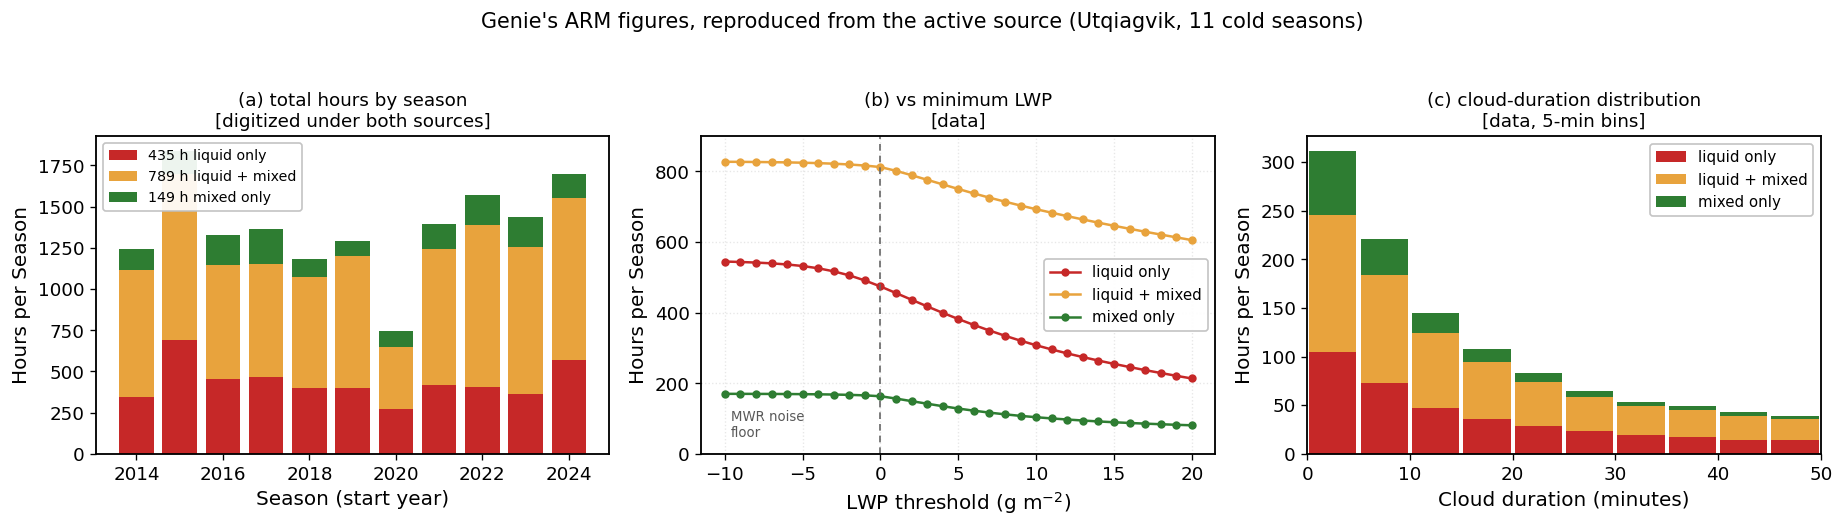

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.2))

# (a) seasonal stacked bars -- always digitized
ax = axes[0]
bottom = np.zeros_like(seasonal_hours["liq_only"])
for c, lab, col in zip(CATS, CAT_LABELS, CAT_COLORS):
    ax.bar(season_start_year, seasonal_hours[c], bottom=bottom, width=0.8,
           color=col, label=f"{seasonal_hours[c].mean():.0f} h {lab}")
    bottom += seasonal_hours[c]
ax.set_xlabel("Season (start year)")
ax.set_ylabel("Hours per Season")
ax.set_title("(a) total hours by season\n[digitized under both sources]", fontsize=11)
ax.legend(fontsize=8.5, loc="upper left")

# (b) LWP threshold curves
ax = axes[1]
for c, lab, col in zip(CATS, CAT_LABELS, CAT_COLORS):
    ax.plot(lwp_threshold_gm2, lwp_hours[c], "o-", ms=4, color=col, label=lab)
ax.set_xlabel(r"LWP threshold (g m$^{-2}$)")
ax.set_ylabel("Hours per Season")
ax.set_title(f"(b) vs minimum LWP\n[{DATA_SOURCE}]", fontsize=11)
ax.set_ylim(0, 900)
ax.xaxis.set_major_locator(MultipleLocator(5))
if (lwp_threshold_gm2 < 0).any():
    ax.axvline(0.0, color="0.4", lw=1.0, ls=(0, (4, 3)))
    ax.annotate("MWR noise\nfloor", xy=(lwp_threshold_gm2.min() + 0.4, 40),
                fontsize=8, color="0.35", ha="left", va="bottom")
ax.grid(alpha=0.3, ls=":")
ax.legend(fontsize=9)

# (c) cloud-duration histogram
ax = axes[2]
edges = ds["hist_edges_min"]
widths = np.diff(edges)
centers = edges[:-1] + widths / 2
bottom = np.zeros_like(centers)
for c, lab, col in zip(CATS, CAT_LABELS, CAT_COLORS):
    ax.bar(centers, ds["hist_hours"][c], bottom=bottom, width=widths * 0.92,
           color=col, label=lab)
    bottom += ds["hist_hours"][c]
ax.set_xlabel("Cloud duration (minutes)")
ax.set_ylabel("Hours per Season")
ax.set_title(f"(c) cloud-duration distribution\n[{DATA_SOURCE}, "
             f"{widths[0]:.0f}-min bins]", fontsize=11)
ax.set_xlim(0, 50)
ax.legend(fontsize=9)

fig.suptitle("Genie's ARM figures, reproduced from the active source "
             "(Utqiagvik, 11 cold seasons)", y=1.04, fontsize=12.5)
fig.tight_layout()
plt.show()

## 4. The duration threshold curve

For a minimum-duration threshold $\tau$, the hours retained are

$$H(\tau) \;=\; \sum_{d \,\ge\, \tau} h(d)$$

where $h(d)$ is the cloud-duration histogram. This is a survival (exceedance)
curve: $H(0)$ is the full record and it falls monotonically.

In [7]:
print(f"[{DATA_SOURCE}]")
print(f"liquid-containing hours per season, no duration cut : {duration_total_h[0]:7.1f}")
print(f"liquid-containing hours per season, LWP > 2 g m-2   : "
      f"{at_lwp(lwp_total_h, 2.0):7.1f}")
print(f"ratio (90 s gap-bridging inflation)                 : "
      f"{duration_total_h[0] / at_lwp(lwp_total_h, 2.0):7.3f}")
print()
print(" tau (min)   liq_only  liq+mixed  mixed_only     TOTAL   % of tau=0")
for t in (0, 5, 10, 15, 20, 30, 45, 60, 90, 120, 180):
    if not np.isclose(duration_threshold_min, t).any():
        continue
    print(f"  {t:6d}   {at_duration(duration_hours['liq_only'], t):8.1f} "
          f"{at_duration(duration_hours['liq_mixed'], t):9.1f} "
          f"{at_duration(duration_hours['mixed_only'], t):10.1f} "
          f"{at_duration(duration_total_h, t):9.1f} "
          f"{100 * at_duration(duration_total_h, t) / duration_total_h[0]:9.1f}")

[data]
liquid-containing hours per season, no duration cut :  1558.9
liquid-containing hours per season, LWP > 2 g m-2   :  1375.1
ratio (90 s gap-bridging inflation)                 :   1.134

 tau (min)   liq_only  liq+mixed  mixed_only     TOTAL   % of tau=0
       0      524.0     855.0      180.0    1558.9     100.0
       5      419.5     713.9      114.6    1248.0      80.1
      10      346.6     603.0       77.9    1027.4      65.9
      15      299.0     525.9       57.7     882.6      56.6
      20      263.1     467.9       44.2     775.2      49.7
      30      211.3     387.8       28.7     627.8      40.3
      45      161.4     305.2       16.5     483.1      31.0
      60      125.0     249.7       10.0     384.7      24.7
      90       80.1     179.3        5.0     264.5      17.0
     120       51.4     132.5        2.0     185.8      11.9
     180       23.9      74.5        0.7      99.0       6.3


## 5. Figure 1 -- the two thresholds on shared axes

Hours per season on y, LWP threshold on the lower (black) axis, cloud-duration
threshold on the upper (blue) axis, each curve drawn in the colour of its own
axis.

The duration axis is cut at 60 min. Beyond that the curve is still falling but
only a quarter of the hours are left, and stretching the axis to 400 min
compresses everything that matters into the first eighth of the panel.

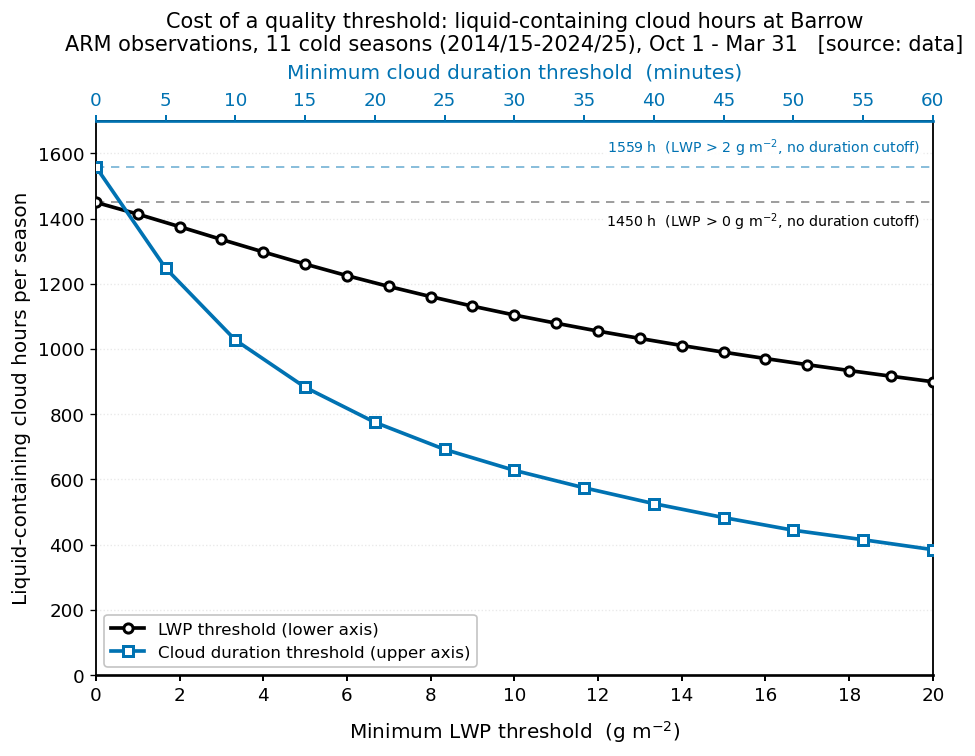

In [15]:
lwp_plot = ((lwp_threshold_gm2 >= LWP_PLOT_RANGE_GM2[0])
            & (lwp_threshold_gm2 <= LWP_PLOT_RANGE_GM2[1]))
dur_plot = duration_threshold_min <= DUR_AXIS_MAX_MIN


def marker_kwargs(n_points: int) -> dict:
    """Marker style that keeps ONE marker per data point legible at any density.

    The `data` source samples cloud duration every 5 min (13 points over
    0-60 min); `digitized_plot` samples it every 1 min (52 points over the same
    span). Both get a marker on every point -- the dense case just gets a
    smaller one so the markers stay separated rather than merging into a band.
    """
    if n_points <= 30:
        return dict(ms=5.5, mfc="white", mew=1.8)
    return dict(ms=3.5, mfc="white", mew=1.0)


lwp_mk = marker_kwargs(int(lwp_plot.sum()))
dur_mk = marker_kwargs(int(dur_plot.sum()))

fig, ax_lwp = plt.subplots(figsize=(9.0, 6.0))
ax_dur = ax_lwp.twiny()

# --- LWP curve, bottom axis, black -----------------------------------------
ax_lwp.plot(lwp_threshold_gm2[lwp_plot], lwp_total_h[lwp_plot], "o-", color=C_LWP,
            lw=2.2, zorder=4, label="LWP threshold (lower axis)", **lwp_mk)
ax_lwp.set_xlabel(r"Minimum LWP threshold  (g m$^{-2}$)", color=C_LWP, labelpad=8)
ax_lwp.tick_params(axis="x", colors=C_LWP, width=1.2)
ax_lwp.set_xlim(*LWP_PLOT_RANGE_GM2)
ax_lwp.xaxis.set_major_locator(MultipleLocator(2))
ax_lwp.spines["bottom"].set_color(C_LWP)
ax_lwp.spines["bottom"].set_linewidth(1.6)

# --- duration curve, top axis, blue ----------------------------------------
ax_dur.plot(duration_threshold_min[dur_plot], duration_total_h[dur_plot], "s-",
            color=C_DUR, lw=2.2, zorder=4,
            label="Cloud duration threshold (upper axis)", **dur_mk)
ax_dur.set_xlabel("Minimum cloud duration threshold  (minutes)", color=C_DUR, labelpad=8)
ax_dur.tick_params(axis="x", colors=C_DUR, width=1.2)
ax_dur.set_xlim(0, DUR_AXIS_MAX_MIN)
ax_dur.xaxis.set_major_locator(MultipleLocator(5))
ax_dur.spines["top"].set_color(C_DUR)
ax_dur.spines["top"].set_linewidth(1.6)
for s in ("bottom", "left", "right"):
    ax_dur.spines[s].set_visible(False)

ax_lwp.set_ylabel("Liquid-containing cloud hours per season")
ax_lwp.set_ylim(0, 1700)
ax_lwp.yaxis.set_major_locator(MultipleLocator(200))
ax_lwp.grid(axis="y", alpha=0.28, ls=":", zorder=0)
ax_lwp.set_axisbelow(True)

# Baselines differ by the gap-bridging rule -- mark both so the offset is explicit.
lwp_base_h = at_lwp(lwp_total_h, 0.0)
_bbox = dict(boxstyle="round,pad=0.22", fc="white", ec="none", alpha=0.9)
ax_lwp.axhline(duration_total_h[0], color=C_DUR, lw=1.0, ls=(0, (5, 4)), alpha=0.55,
               zorder=1)
ax_lwp.axhline(lwp_base_h, color=C_LWP, lw=1.0, ls=(0, (5, 4)), alpha=0.45, zorder=1)
ax_lwp.annotate(f"{duration_total_h[0]:.0f} h  (LWP > 2 g m$^{{-2}}$, no duration cutoff)",
                xy=(0.985, duration_total_h[0]), xycoords=("axes fraction", "data"),
                xytext=(0, 5), textcoords="offset points",
                ha="right", va="bottom", fontsize=8.5, color=C_DUR, bbox=_bbox)
ax_lwp.annotate(f"{lwp_base_h:.0f} h  (LWP > 0 g m$^{{-2}}$, no duration cutoff)",
                xy=(0.985, lwp_base_h), xycoords=("axes fraction", "data"),
                xytext=(0, -5), textcoords="offset points",
                ha="right", va="top", fontsize=8.5, color=C_LWP, bbox=_bbox)

handles = ax_lwp.get_legend_handles_labels()[0] + ax_dur.get_legend_handles_labels()[0]
labels = ax_lwp.get_legend_handles_labels()[1] + ax_dur.get_legend_handles_labels()[1]
ax_lwp.legend(handles, labels, loc="lower left", fontsize=10)

ax_lwp.set_title("Cost of a quality threshold: liquid-containing cloud hours at Barrow\n"
                 "ARM observations, 11 cold seasons (2014/15-2024/25), Oct 1 - Mar 31"
                 f"   [source: {DATA_SOURCE}]", pad=42)
fig.savefig(FIG_DIR
            / f"barrow_liquid_hours_vs_lwp_and_duration_thresholds_{DATA_SOURCE}.png", dpi=350)
plt.show()

The dual axis does what it should, and the shape comparison is honest, but the
panel has a weakness worth naming: the horizontal alignment of the two curves
is set entirely by the choice of 20 g m$^{-2}$ against 60 min. Slide the
duration axis to 0-30 min and the blue curve looks twice as steep. A reader
cannot tell which threshold is more expensive without knowing that the axis
ranges were chosen arbitrarily, and nothing in the panel says so.

## 6. Figure 2 -- retained fraction, and the threshold exchange rate

Two panels that remove the arbitrary scaling.

**(a)** Both curves as the *fraction of liquid-containing hours retained*, each
normalized to its own zero-threshold total (LWP > 0 for the black curve, no
duration cut for the blue). The differing baselines cancel, so the curves
become directly comparable and nothing depends on where the axes are cut.

**(b)** The exchange rate between the two knobs: for each LWP threshold, the
duration threshold that discards the same fraction of the record. This is the
panel that answers "how strict is my LWP cut, in minutes?"

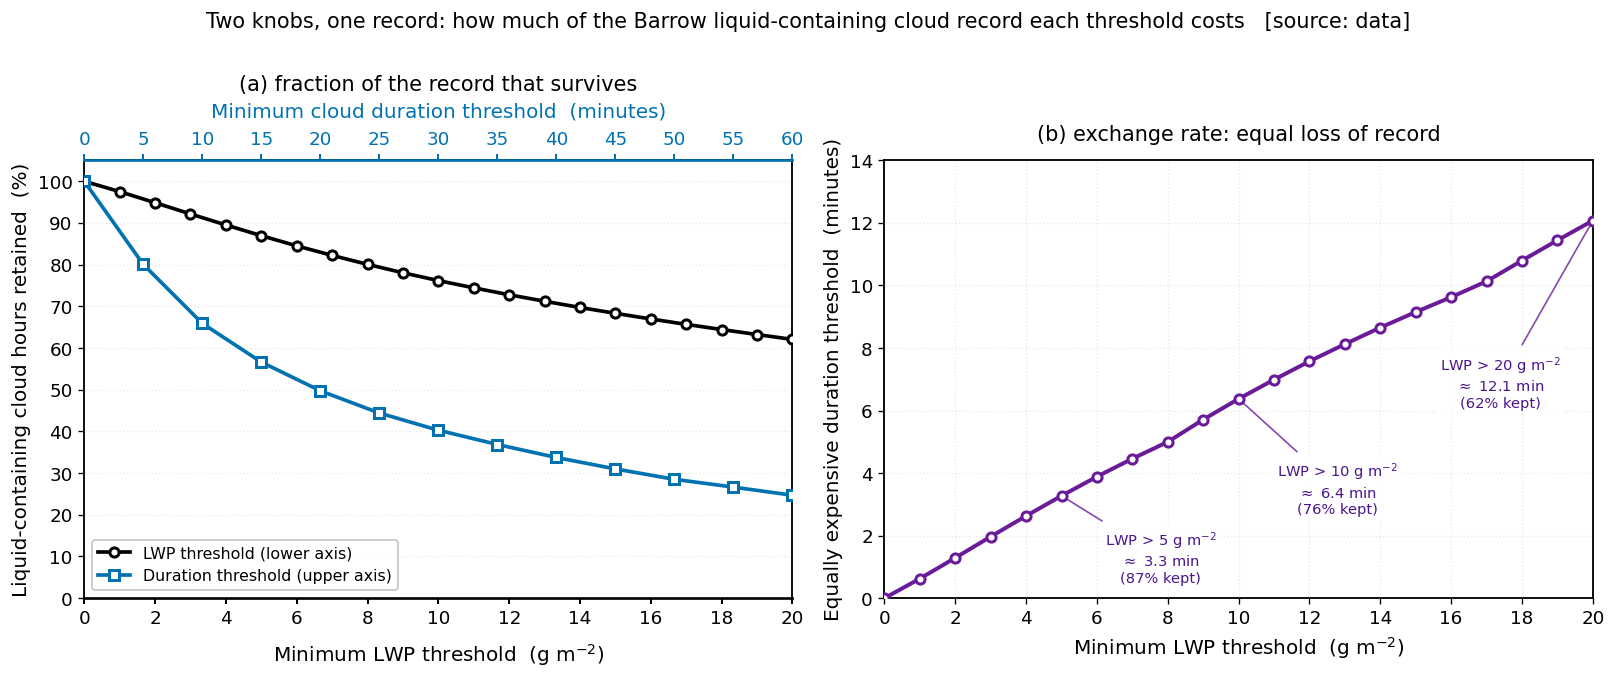

In [13]:
lwp_frac = lwp_total_h / at_lwp(lwp_total_h, 0.0)
dur_frac = duration_total_h / duration_total_h[0]

# Invert the (monotone decreasing) duration curve at each LWP threshold.
equiv_duration_min = np.interp(
    lwp_frac[::-1], dur_frac[::-1], duration_threshold_min[::-1]
)[::-1]

fig, (axa, axb) = plt.subplots(1, 2, figsize=(13.6, 5.6))

# --- (a) retained fraction --------------------------------------------------
ax_dur2 = axa.twiny()
axa.plot(lwp_threshold_gm2[lwp_plot], 100 * lwp_frac[lwp_plot], "o-", color=C_LWP,
         lw=2.2, zorder=4, label="LWP threshold (lower axis)", **lwp_mk)
ax_dur2.plot(duration_threshold_min[dur_plot], 100 * dur_frac[dur_plot], "s-",
             color=C_DUR, lw=2.2, zorder=4,
             label="Duration threshold (upper axis)", **dur_mk)

axa.set_xlim(*LWP_PLOT_RANGE_GM2)
axa.xaxis.set_major_locator(MultipleLocator(2))
axa.set_xlabel(r"Minimum LWP threshold  (g m$^{-2}$)", color=C_LWP, labelpad=8)
axa.tick_params(axis="x", colors=C_LWP, width=1.2)
axa.spines["bottom"].set_color(C_LWP)
axa.spines["bottom"].set_linewidth(1.6)

ax_dur2.set_xlim(0, DUR_AXIS_MAX_MIN)
ax_dur2.xaxis.set_major_locator(MultipleLocator(5))
ax_dur2.set_xlabel("Minimum cloud duration threshold  (minutes)", color=C_DUR, labelpad=8)
ax_dur2.tick_params(axis="x", colors=C_DUR, width=1.2)
ax_dur2.spines["top"].set_color(C_DUR)
ax_dur2.spines["top"].set_linewidth(1.6)
for s in ("bottom", "left", "right"):
    ax_dur2.spines[s].set_visible(False)

axa.set_ylabel("Liquid-containing cloud hours retained  (%)")
axa.set_ylim(0, 105)
axa.yaxis.set_major_locator(MultipleLocator(10))
axa.grid(axis="y", alpha=0.28, ls=":")
axa.set_axisbelow(True)
# for lvl in (90, 75, 50):
#     axa.axhline(lvl, color="0.45", lw=0.9, ls=(0, (2, 3)), zorder=1)
#     axa.annotate(f"{lvl}%", xy=(0.012, lvl), xycoords=("axes fraction", "data"),
#                  va="bottom", ha="left", fontsize=8.5, color="0.35")

h = axa.get_legend_handles_labels()[0] + ax_dur2.get_legend_handles_labels()[0]
l = axa.get_legend_handles_labels()[1] + ax_dur2.get_legend_handles_labels()[1]
axa.legend(h, l, loc="lower left", fontsize=9.5)
axa.set_title("(a) fraction of the record that survives", pad=42)

# --- (b) exchange rate ------------------------------------------------------
axb.plot(lwp_threshold_gm2[lwp_plot], equiv_duration_min[lwp_plot], "o-",
         color="#6A1B9A", lw=2.4, zorder=4, **lwp_mk)
axb.set_xlabel(r"Minimum LWP threshold  (g m$^{-2}$)")
axb.set_ylabel("Equally expensive duration threshold  (minutes)")
axb.set_xlim(*LWP_PLOT_RANGE_GM2)
axb.set_ylim(0, 14)
axb.xaxis.set_major_locator(MultipleLocator(2))
axb.yaxis.set_major_locator(MultipleLocator(2))
axb.grid(alpha=0.28, ls=":")
axb.set_axisbelow(True)
axb.set_title("(b) exchange rate: equal loss of record", pad=12)

for x, tx, ty in ((5.0, 7.8, 1.3), (10.0, 12.8, 3.5), (20.0, 17.4, 6.9)):
    y = float(np.interp(x, lwp_threshold_gm2[lwp_plot], equiv_duration_min[lwp_plot]))
    pct = 100 * at_lwp(lwp_frac, x)
    axb.annotate(f"LWP > {x:.0f} g m$^{{-2}}$\n$\\approx$ {y:.1f} min\n({pct:.0f}% kept)",
                 xy=(x, y), xytext=(tx, ty), fontsize=8.8, ha="center", va="center",
                 color="#4A148C",
                 bbox=dict(boxstyle="round,pad=0.28", fc="white", ec="none", alpha=0.9),
                 arrowprops=dict(arrowstyle="-", color="#6A1B9A", lw=1.0, alpha=0.8))

fig.suptitle("Two knobs, one record: how much of the Barrow liquid-containing cloud "
             f"record each threshold costs   [source: {DATA_SOURCE}]",
             y=1.005, fontsize=12.5)
fig.tight_layout()
fig.savefig(FIG_DIR
            / f"barrow_liquid_hours_threshold_retention_and_exchange_{DATA_SOURCE}.png", dpi=350)
plt.show()

## 7. What the curves say

In [10]:
print(f"[{DATA_SOURCE}]  liquid-containing hours per season\n")
print(f"  {'threshold':<28s}{'hours':>9s}{'% kept':>9s}")
print(f"  {'none (LWP > 0)':<28s}{at_lwp(lwp_total_h, 0.0):9.0f}{100.0:9.1f}")
for x in (5.0, 10.0, 20.0):
    print(f"  {'LWP > ' + format(x, '.0f') + ' g m-2':<28s}"
          f"{at_lwp(lwp_total_h, x):9.0f}{100 * at_lwp(lwp_frac, x):9.1f}")
for t in (5, 10, 20):
    print(f"  {'duration >= ' + str(t) + ' min':<28s}"
          f"{at_duration(duration_total_h, t):9.0f}"
          f"{100 * at_duration(dur_frac, t):9.1f}")

print(f"\n  LWP curve slope, 0 to 20 g m-2 : "
      f"{(at_lwp(lwp_total_h, 0.0) - at_lwp(lwp_total_h, 20.0)) / 20:.1f} "
      f"h/season per g m-2")
print(f"  exchange rate at 20 g m-2      : "
      f"{float(np.interp(20.0, lwp_threshold_gm2[lwp_plot], equiv_duration_min[lwp_plot])):.1f}"
      f" min")

print("\n\nfraction of each category retained\n")
print(f"  {'threshold':<26s}" + "".join(f"{lab:>17s}" for lab in CAT_LABELS))
for x in (5.0, 10.0, 20.0):
    vals = "".join(
        f"{100 * at_lwp(lwp_hours[c], x) / at_lwp(lwp_hours[c], 0.0):16.1f}%"
        for c in CATS
    )
    print(f"  {'LWP > ' + format(x, '.0f') + ' g m-2':<26s}" + vals)
for t in (5, 10, 20):
    vals = "".join(
        f"{100 * at_duration(duration_hours[c], t) / duration_hours[c][0]:16.1f}%"
        for c in CATS
    )
    print(f"  {'duration >= ' + str(t) + ' min':<26s}" + vals)

[data]  liquid-containing hours per season

  threshold                       hours   % kept
  none (LWP > 0)                   1450    100.0
  LWP > 5 g m-2                    1260     86.9
  LWP > 10 g m-2                   1104     76.2
  LWP > 20 g m-2                    900     62.1
  duration >= 5 min                1248     80.1
  duration >= 10 min               1027     65.9
  duration >= 20 min                775     49.7

  LWP curve slope, 0 to 20 g m-2 : 27.5 h/season per g m-2
  exchange rate at 20 g m-2      : 12.1 min


fraction of each category retained

  threshold                       liquid only   liquid + mixed       mixed only
  LWP > 5 g m-2                         80.5%            92.4%            78.6%
  LWP > 10 g m-2                        64.9%            85.3%            63.5%
  LWP > 20 g m-2                        45.0%            74.5%            49.5%
  duration >= 5 min                     80.1%            83.5%            63.7%
  duration >= 10 min  

Numbers quoted below are from the default `data` source. `digitized_plot`
gives the same percentages to within 0.55 points over the 0-60 min range
plotted here; section 8 prints the worst case over the full sweep.

**Duration is by far the more expensive knob.** Ten minutes of required
persistence costs 34% of the record; the *entire* 20 g m$^{-2}$ LWP sweep,
which is as far as Genie's figure goes, costs 38%. Panel (b) puts the exchange
rate at a nearly constant **0.6 min per g m$^{-2}$** across the whole sweep
(equivalently, 1 minute of required persistence costs about as much as
1.6 g m$^{-2}$ of LWP), so the full 20 g m$^{-2}$ cut buys the same loss as a
12-minute persistence requirement, and nothing milder.

The reason is in the cloud-duration distribution reproduced in panel (c) of
section 3: it is steeply peaked at short durations with a long thin tail. Short
episodes are individually negligible but there are enough of them that they
carry a third of the total hours. The LWP curve, by contrast, is close to
linear over 0-20 g m$^{-2}$, losing about 27 h/season per g m$^{-2}$ -- there
is no pile-up of hours at low LWP the way there is at short duration.

**By category, the two knobs do not fall on the same one.** `liq_mixed`
survives both best (74.5% retained at LWP > 20 g m$^{-2}$, 54.7% at 20 min,
against 45-50% and 25-50% for the other two). That is close to a definition: an
episode is classified `liq_mixed` only if it contains both a liquid-only and a
mixed-phase period, which forces it to be long, and long episodes carry more
liquid. The interesting split is between the other two categories. The LWP knob
bites hardest on `liq_only` (45.0% retained at 20 g m$^{-2}$, against 49.5% for
`mixed_only`); the duration knob bites hardest on `mixed_only` by a wide margin
(24.6% retained at 20 min, against 50.2% for `liq_only`). Purely mixed-phase
episodes at Barrow are the short-lived ones.

## 8. The two sources, differenced

Loads both and compares them, so the digitization can be checked against the
CSV it was standing in for.

In [11]:
both = {}
for name, loader in LOADERS.items():
    try:
        both[name] = loader()
    except (FileNotFoundError, ValueError) as exc:
        print(f"could not load {name!r}: {exc}")

if len(both) == 2:
    a, b = both["data"], both["digitized_plot"]

    print("LWP sweep, liquid-containing hours per season\n")
    print(f"  {'LWP':>5s}{'data':>10s}{'digitized':>12s}{'diff':>9s}{'% diff':>9s}")
    tot_a = sum(a["lwp_hours"][c] for c in CATS)
    tot_b = sum(b["lwp_hours"][c] for c in CATS)
    for x in (0.0, 1.0, 2.0, 5.0, 10.0, 15.0, 20.0):
        va = tot_a[int(np.flatnonzero(np.isclose(a["lwp_threshold_gm2"], x))[0])]
        vb = tot_b[int(np.flatnonzero(np.isclose(b["lwp_threshold_gm2"], x))[0])]
        print(f"  {x:5.0f}{va:10.1f}{vb:12.1f}{vb - va:9.1f}{100 * (vb - va) / va:9.2f}")

    print("\nDuration sweep, fraction of the record retained (%)\n")
    print(f"  {'tau':>5s}{'data':>10s}{'digitized':>12s}{'diff':>9s}")
    fa = sum(a["duration_hours"][c] for c in CATS)
    fb = sum(b["duration_hours"][c] for c in CATS)
    fa = 100 * fa / fa[0]
    fb = 100 * fb / fb[0]
    for t in (0, 5, 10, 15, 20, 30, 45, 60):
        ia = np.flatnonzero(np.isclose(a["duration_threshold_min"], t))
        ib = np.flatnonzero(np.isclose(b["duration_threshold_min"], t))
        if ia.size and ib.size:
            print(f"  {t:5d}{fa[ia[0]]:10.1f}{fb[ib[0]]:12.1f}"
                  f"{fb[ib[0]] - fa[ia[0]]:9.2f}")

    # Largest disagreement anywhere on the common part of the duration sweep.
    common = np.intersect1d(a["duration_threshold_min"], b["duration_threshold_min"])
    ja = np.searchsorted(a["duration_threshold_min"], common)
    jb = np.searchsorted(b["duration_threshold_min"], common)
    max_pt = float(np.abs(fb[jb] - fa[ja]).max())
    max_at = float(common[int(np.abs(fb[jb] - fa[ja]).argmax())])
    print("\nThe retained-fraction curves -- which every conclusion above rests on --")
    print(f"never differ by more than {max_pt:.2f} percentage points "
          f"(worst at tau = {max_at:.0f} min).")

LWP sweep, liquid-containing hours per season

    LWP      data   digitized     diff   % diff
      0    1449.6      1450.8      1.2     0.08
      1    1413.6      1413.7      0.1     0.01
      2    1375.1      1376.6      1.5     0.11
      5    1260.4      1260.4      0.0     0.00
     10    1104.2      1102.9     -1.3    -0.11
     15     990.3       991.0      0.7     0.08
     20     899.6       900.8      1.2     0.14

Duration sweep, fraction of the record retained (%)

    tau      data   digitized     diff
      0     100.0       100.0    -0.00
      5      80.1        80.3     0.26
     10      65.9        66.2     0.28
     15      56.6        56.8     0.23
     20      49.7        49.9     0.15
     30      40.3        40.2    -0.10
     45      31.0        30.8    -0.23
     60      24.7        24.1    -0.53

The retained-fraction curves -- which every conclusion above rests on --
never differ by more than 0.73 percentage points (worst at tau = 90 min).


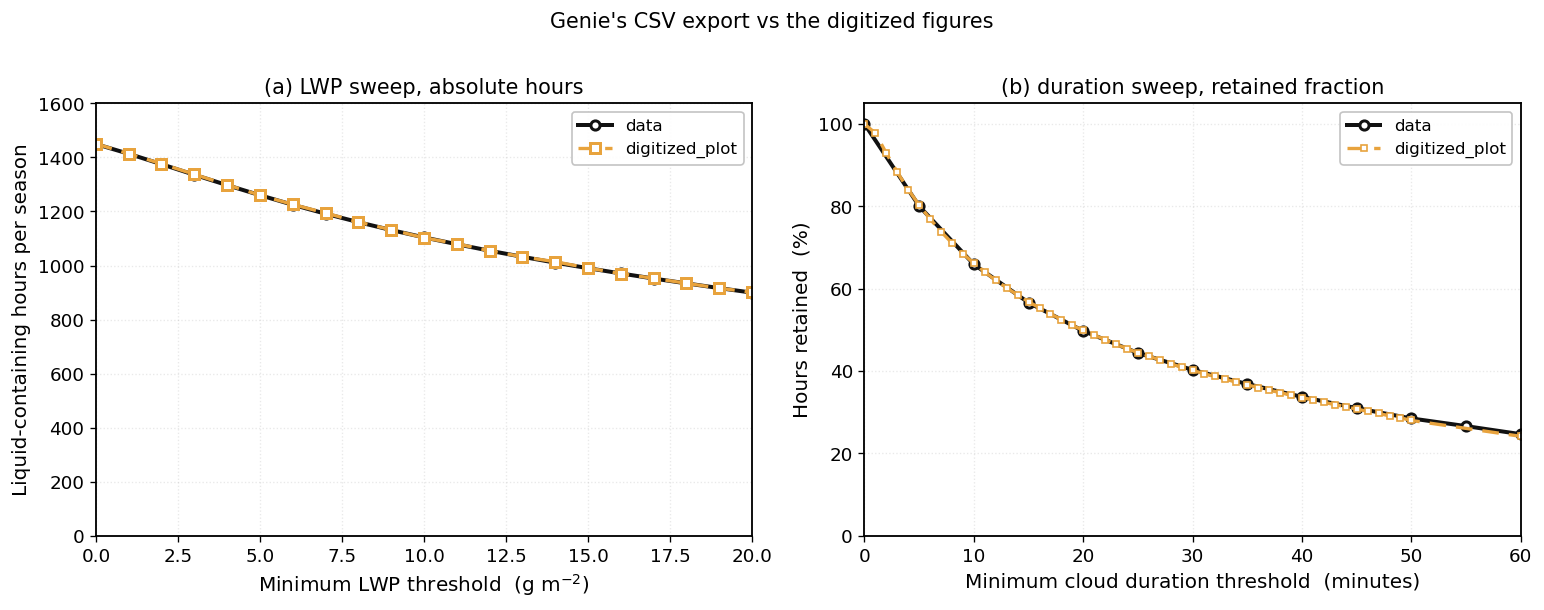

In [12]:
if len(both) == 2:
    fig, (axa, axb) = plt.subplots(1, 2, figsize=(13.0, 5.0))
    styles = {"data": dict(color="#111111", lw=2.4, ls="-", marker="o"),
              "digitized_plot": dict(color="#E8A33D", lw=2.0, ls=(0, (5, 3)),
                                     marker="s")}
    for name, d in both.items():
        tot = sum(d["lwp_hours"][c] for c in CATS)
        m = ((d["lwp_threshold_gm2"] >= LWP_PLOT_RANGE_GM2[0])
             & (d["lwp_threshold_gm2"] <= LWP_PLOT_RANGE_GM2[1]))
        axa.plot(d["lwp_threshold_gm2"][m], tot[m], label=name,
                 **marker_kwargs(int(m.sum())), **styles[name])

        dtot = sum(d["duration_hours"][c] for c in CATS)
        m2 = d["duration_threshold_min"] <= DUR_AXIS_MAX_MIN
        axb.plot(d["duration_threshold_min"][m2], 100 * dtot[m2] / dtot[0],
                 label=name, **marker_kwargs(int(m2.sum())), **styles[name])

    axa.set_xlabel(r"Minimum LWP threshold  (g m$^{-2}$)")
    axa.set_ylabel("Liquid-containing hours per season")
    axa.set_xlim(*LWP_PLOT_RANGE_GM2)
    axa.set_ylim(0, 1600)
    axa.grid(alpha=0.28, ls=":")
    axa.set_axisbelow(True)
    axa.legend(fontsize=10)
    axa.set_title("(a) LWP sweep, absolute hours")

    axb.set_xlabel("Minimum cloud duration threshold  (minutes)")
    axb.set_ylabel("Hours retained  (%)")
    axb.set_xlim(0, DUR_AXIS_MAX_MIN)
    axb.set_ylim(0, 105)
    axb.grid(alpha=0.28, ls=":")
    axb.set_axisbelow(True)
    axb.legend(fontsize=10)
    axb.set_title("(b) duration sweep, retained fraction")

    fig.suptitle("Genie's CSV export vs the digitized figures", y=1.01, fontsize=12.5)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "barrow_liquid_hours_source_comparison.png")
    plt.show()